In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:
path_to_df = Path(r"basic_PDB.csv")

In [14]:
df = pd.read_csv(path_to_df)

In [15]:
df.head()

,Unnamed: 0,pdbid,resolution,deposition_date,exptl_method,chain_number
0,0,1jdv,2.00,2001-06-15,['X-RAY DIFFRACTION'],6
1,1,5a9i,2.84,2015-07-21,['X-RAY DIFFRACTION'],3
2,2,1jdw,1.90,1997-01-22,['X-RAY DIFFRACTION'],1
3,3,1jdp,2.00,2001-06-14,['X-RAY DIFFRACTION'],3
4,4,1jdr,1.50,2001-06-14,['X-RAY DIFFRACTION'],1


In [16]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [17]:
df.head()

,pdbid,resolution,deposition_date,exptl_method,chain_number
0,1jdv,2.00,2001-06-15,['X-RAY DIFFRACTION'],6
1,5a9i,2.84,2015-07-21,['X-RAY DIFFRACTION'],3
2,1jdw,1.90,1997-01-22,['X-RAY DIFFRACTION'],1
3,1jdp,2.00,2001-06-14,['X-RAY DIFFRACTION'],3
4,1jdr,1.50,2001-06-14,['X-RAY DIFFRACTION'],1


In [18]:
print(df.shape)

(1500171, 5)


In [19]:
df["pdbid"].nunique()

250839

In [20]:
df[df["pdbid"] == "1jdv"]

,pdbid,resolution,deposition_date,exptl_method,chain_number
0,1jdv,2.0,2001-06-15,['X-RAY DIFFRACTION'],6
76633,1jdv,2.0,2001-06-15,['X-RAY DIFFRACTION'],6
424125,1jdv,2.0,2001-06-15,['X-RAY DIFFRACTION'],6
618530,1jdv,2.0,2001-06-15,['X-RAY DIFFRACTION'],6
998841,1jdv,2.0,2001-06-15,['X-RAY DIFFRACTION'],6
1177393,1jdv,2.0,2001-06-15,['X-RAY DIFFRACTION'],6


In [21]:
df.isna().sum()

pdbid                  0
resolution         89026
deposition_date        0
exptl_method           0
chain_number           0
dtype: int64

In [22]:
df['nan_count'] = df.isna().sum(axis=1)
df = df.sort_values('nan_count').drop_duplicates(subset=['pdbid']).drop(columns='nan_count')

In [23]:
print(df.shape)

(250839, 5)


In [24]:
df['deposition_date'] = pd.to_datetime(df['deposition_date'])
df['year'] = df['deposition_date'].dt.year
df.head()

,pdbid,resolution,deposition_date,exptl_method,chain_number,year
0,1jdv,2.00,2001-06-15,['X-RAY DIFFRACTION'],6,2001
983744,6ni7,1.15,2018-12-26,['X-RAY DIFFRACTION'],2,2018
983743,6hco,3.58,2018-08-15,['ELECTRON MICROSCOPY'],6,2018
983742,9gg2,2.75,2024-08-13,['ELECTRON MICROSCOPY'],13,2024
983741,418d,2.40,1998-08-12,['X-RAY DIFFRACTION'],2,1998


In [25]:
df.describe()

,resolution,chain_number,year
count,235996.000000,250839.000000,250839.000000
mean,2.351685,4.379387,2014.500492
std,1.319212,15.713021,7.875848
min,0.480000,0.000000,1972.000000
25%,1.795000,1.000000,2009.000000
50%,2.125000,2.000000,2016.000000
75%,2.700000,4.000000,2021.000000
max,70.000000,1996.000000,2026.000000


<Axes: >

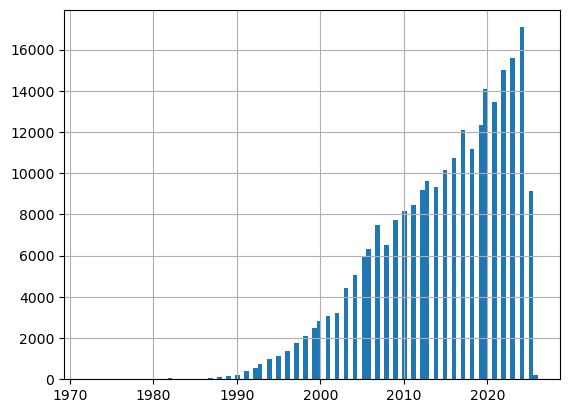

In [26]:
df['year'].hist(bins=100)

In [27]:
df["exptl_method"].value_counts()

['X-RAY DIFFRACTION']                                                          202768
['ELECTRON MICROSCOPY']                                                         32627
['SOLUTION NMR']                                                                14547
['ELECTRON CRYSTALLOGRAPHY']                                                      276
['SOLID-STATE NMR']                                                               175
['NEUTRON DIFFRACTION', 'X-RAY DIFFRACTION', 'HYBRID']                            168
['NEUTRON DIFFRACTION']                                                            88
['SOLUTION NMR', 'SOLUTION SCATTERING', 'HYBRID']                                  42
['FIBER DIFFRACTION']                                                              38
['SOLUTION SCATTERING']                                                            32
['POWDER DIFFRACTION']                                                             21
['SOLUTION SCATTERING', 'X-RAY DIFFRACTION', 'HYBRID']

In [28]:
import ast

df['exptl_method_str'] = df['exptl_method'].apply(
    lambda x: ", ".join(ast.literal_eval(x))
)

df.value_counts(subset='exptl_method_str')

exptl_method_str
X-RAY DIFFRACTION                                                    202768
ELECTRON MICROSCOPY                                                   32627
SOLUTION NMR                                                          14547
ELECTRON CRYSTALLOGRAPHY                                                276
SOLID-STATE NMR                                                         175
NEUTRON DIFFRACTION, X-RAY DIFFRACTION, HYBRID                          168
NEUTRON DIFFRACTION                                                      88
SOLUTION NMR, SOLUTION SCATTERING, HYBRID                                42
FIBER DIFFRACTION                                                        38
SOLUTION SCATTERING                                                      32
POWDER DIFFRACTION                                                       21
SOLUTION SCATTERING, X-RAY DIFFRACTION, HYBRID                           11
ELECTRON MICROSCOPY, SOLID-STATE NMR, HYBRID                           

In [29]:
categories = [
    'X-RAY DIFFRACTION',
    'ELECTRON MICROSCOPY',
    'SOLUTION NMR'
]

df_filtered = df[df['exptl_method_str'].isin(categories)]

In [30]:
counts = (
    df_filtered
    .groupby(['year', 'exptl_method_str'])
    .size()
    .reset_index(name='count')
)

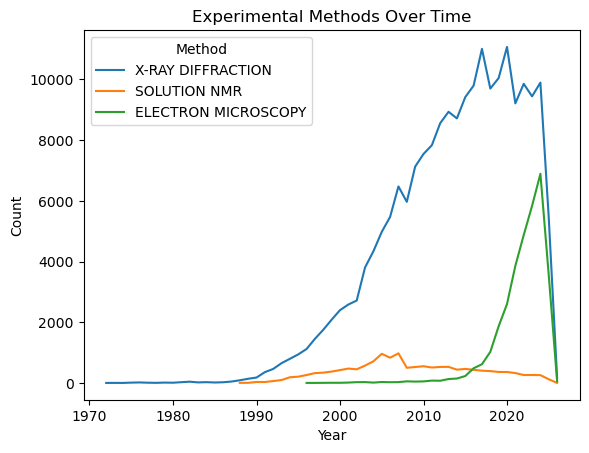

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.lineplot(
    data=counts,
    x='year',
    y='count',
    hue='exptl_method_str'
)

plt.title('Experimental Methods Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Method')
plt.show()

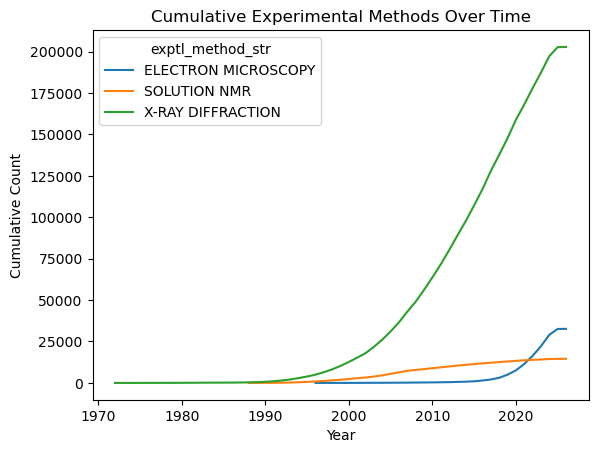

In [32]:
counts = counts.sort_values(['exptl_method_str', 'year'])
counts['cumulative'] = (
    counts.groupby('exptl_method_str')['count']
    .cumsum()
)


plt.figure()
sns.lineplot(
    data=counts,
    x='year',
    y='cumulative',
    hue='exptl_method_str'
)

plt.title('Cumulative Experimental Methods Over Time')
plt.xlabel('Year')
plt.ylabel('Cumulative Count')
plt.show()

In [34]:
df_filtered.to_csv("filtered_basic_PDB.csv", index=False)